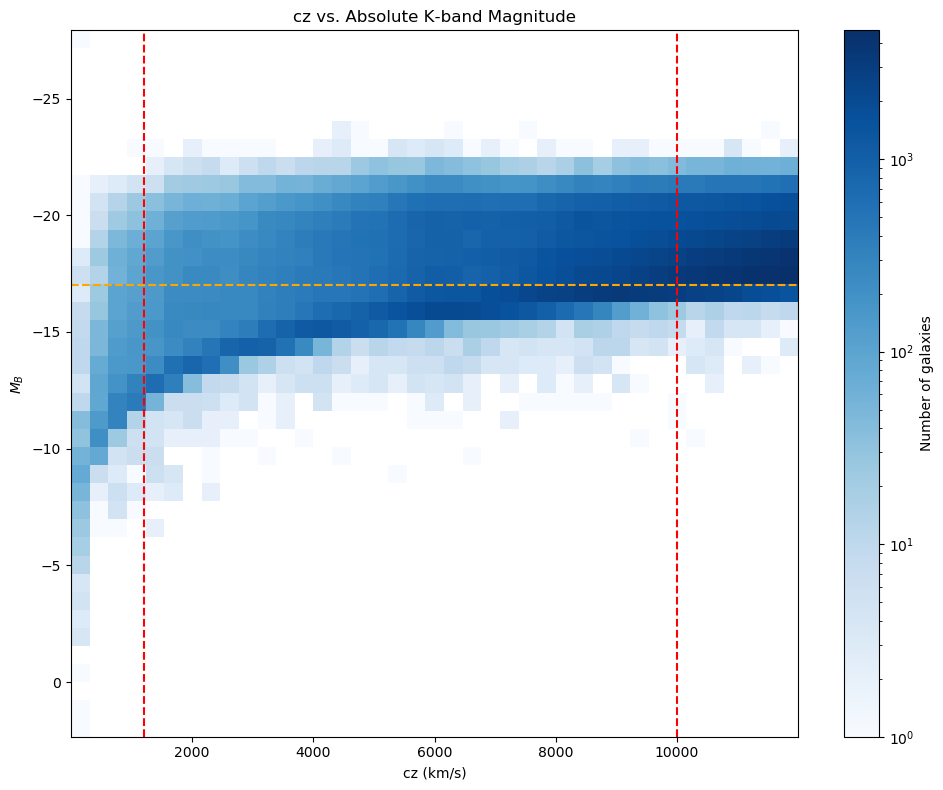

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class Config:
    """Configuration parameters for the analysis."""
    GLADE_FILE = "../data/GLADE_zhelio_lt0.1_dL_lt300.txt"
    PLOTS_DIR = "../plots"

    MIN_CZ = 0
    MAX_CZ = 12000
    CZ_MINCUT = 1200.0
    CZ_MAXCUT = 10000.0
    MB_CUT = -17.0
    MAX_DEC = 45.0

    MAX_DL = 150.0


def read_GLADE(cols_to_use, cz_min=Config.MIN_CZ,
               cz_max=Config.MAX_CZ,
               filename=Config.GLADE_FILE):
    """Read and filter GLADE catalog."""
    from get_masks import get_milkyway_mask

    c = 299792.458  # km/s
    chunksize = 200_000

    # Read header
    with open(filename, 'r') as f:
        header = f.readline().lstrip('#').split()

    filtered_chunks = []

    for chunk in pd.read_csv(
        filename,
        sep=r'\s+',
        names=header,
        usecols=cols_to_use,
        skiprows=1,
        chunksize=chunksize
    ):
        # Distance-flag cut
        chunk = chunk.loc[chunk["dist_flag"] != 0].copy()

        # cz
        chunk["cz"] = c * chunk["z_cmb"]

        # Basic cuts
        chunk = chunk.loc[
            (chunk["cz"] > cz_min) &
            (chunk["cz"] < cz_max)
        ].copy()

        # Absolute magnitude
        chunk["M_B"] = chunk["B"] - 5 * np.log10(chunk["d_L"]) - 25

        # Finite values only
        mask = (
            np.isfinite(chunk["M_B"]) &
            np.isfinite(chunk["d_L"]) &
            np.isfinite(chunk["RA"]) &
            np.isfinite(chunk["Dec"])
        )
        filtered_chunks.append(chunk.loc[mask])

    df = pd.concat(filtered_chunks, ignore_index=True)

    # Apply Milky Way mask (assumed boolean)
    mw_mask = get_milkyway_mask(df["RA"].values, df["Dec"].values)
    df = df.loc[mw_mask]

    # Declination cut
    df = df.loc[df["Dec"] < Config.MAX_DEC]

    return df


def plot_cz_vs_MB(df, savepath=None):
    """
    Create a 2D histogram of cz vs. M_K for the galaxy sample.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns 'cz' and 'M_K'.
    savepath : str, optional
        Full path to save the figure. If None, the plot is only displayed.
    """
    import matplotlib.colors as mcolors

    # Drop any remaining NaN values in the relevant columns
    df_clean = df.dropna(subset=['cz', 'M_B'])

    # Define bin edges – 50 bins in each direction
    cz_bins = np.linspace(df_clean['cz'].min(), df_clean['cz'].max(), 40)
    mk_bins = np.linspace(df_clean['M_B'].min(), df_clean['M_B'].max(), 40)

    # Create the 2D histogram with a logarithmic colour scale
    plt.figure(figsize=(10, 8))
    hist, xedges, yedges, im = plt.hist2d(
        df_clean['cz'], df_clean['M_B'],
        bins=[cz_bins, mk_bins],
        cmap='Blues',
        norm=mcolors.LogNorm()          # better for counting galaxies
    )

    # Add horizontal and vertical lines for cuts
    plt.axvline(Config.CZ_MINCUT, color='red', linestyle='--', label=f'cz > {Config.CZ_MINCUT} km/s')
    plt.axhline(Config.MB_CUT, color='orange', linestyle='--', label=f'M_B < {Config.MB_CUT}')
    plt.axvline(Config.CZ_MAXCUT, color='red', linestyle='--', label=f'cz < {Config.CZ_MINCUT} km/s')

    # Add colour bar and labels
    plt.colorbar(label='Number of galaxies')
    plt.xlabel('cz (km/s)')
    plt.ylabel(r'$M_B$')
    plt.title('cz vs. Absolute K‑band Magnitude')

    # Optionally invert the y‑axis so brighter (more negative) values appear at the top
    plt.gca().invert_yaxis()

    plt.grid(False)                     # grid can be distracting on a 2D histogram
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

if __name__ == "__main__":
    cols_to_use = ["RA", "Dec", "z_cmb", "d_L", "B", "dist_flag"]
    df = read_GLADE(cols_to_use)

    # Apply the absolute magnitude cut (brighter than MK_CUT)
    #df = df[df['M_B'] < Config.MB_CUT]

    # Generate the 2D histogram and save it
    plot_cz_vs_MB(df, savepath=f"{Config.PLOTS_DIR}/cz_vs_MB.png")
